In [1]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#CHART STYLE

sns.set_style("whitegrid")

In [3]:
#LOADING DATA

data_dir = 'processed_data/'
X_train = pd.read_csv(f"{data_dir}X_train_selected_100.csv", index_col=0)
X_test = pd.read_csv(f"{data_dir}X_test_selected_100.csv", index_col=0)
y_train = pd.read_csv(f"{data_dir}y_train.csv", index_col=0)
y_test = pd.read_csv(f"{data_dir}y_test.csv", index_col=0)

In [4]:
#CONVERSION OF LABELS TO FLAT BOARD (SKLEARN REQUIRED)

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()
print(f"Training data: {X_train.shape}")
print(f"Test data:    {X_test.shape}")


Training data: (487, 100)
Test data:    (122, 100)


MODEL: SVM 
MODEL ACCURACY: 98.36% NUMBER OF ERRORS: 2 out of 122 patients


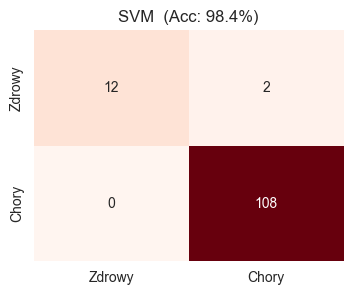

MODEL: Random Forest
MODEL ACCURACY: 98.36% NUMBER OF ERRORS: 2 out of 122 patients


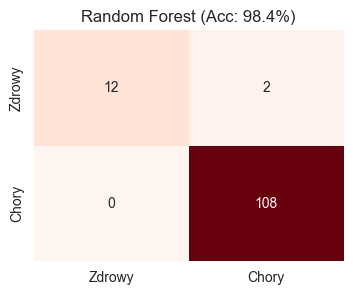

MODEL: Regresja Logistyczna
MODEL ACCURACY: 99.18% NUMBER OF ERRORS: 1 out of 122 patients


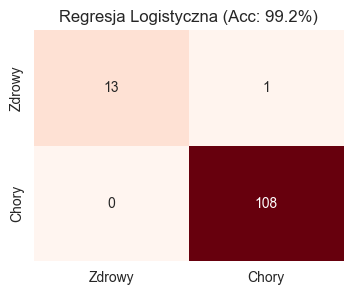

MODEL: Gradient Boosting
MODEL ACCURACY: 99.18% NUMBER OF ERRORS: 1 out of 122 patients


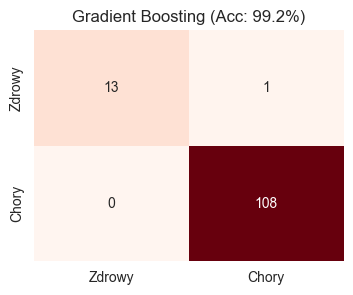

MODEL: k-NN
MODEL ACCURACY: 99.18% NUMBER OF ERRORS: 1 out of 122 patients


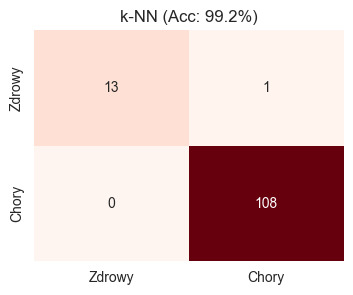

In [5]:
#DEFINITION OF MODELS


models = {
    "SVM ": SVC(kernel='linear', C=1.0, probability=True, class_weight='balanced', random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42),

    "Regresja Logistyczna": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),

    "k-NN": KNeighborsClassifier(n_neighbors=5)
}

#TRAINING AND ASSESSMENT

for name, model in models.items():
    print(f"MODEL: {name}")

    #TRAINING
    model.fit(X_train, y_train)

    #PREDICTION
    y_pred = model.predict(X_test)

    #SCORES
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    #NUMBER OF MISTAKES

    errors = cm[0][1] + cm[1][0]

    print(f"MODEL ACCURACY: {acc:.2%} NUMBER OF ERRORS: {errors} out of 122 patients")

    #DRAWING MATRICES

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds' if errors > 0 else 'Greens', cbar=False,
                xticklabels=['Zdrowy', 'Chory'], yticklabels=['Zdrowy', 'Chory'])
    plt.title(f"{name} (Acc: {acc:.1%})")

    #SAVING TO FILE
    filename = f"macierz_{name.strip().replace(' ', '_').lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()